In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [17]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

__Loading the Dataset__

In [11]:
df = pd.read_csv("data/raw/Topic2_credit_assignment_dataset.csv")
list(df)

['Unnamed: 0',
 'SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

__Dropping the column "Unnamed"__

In [12]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1.0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


__Seperating the labeled and unlabeled datapoints__

In [22]:
df_labeled   = df[df['SeriousDlqin2yrs'].notna()].copy()
df_unlabeled = df[df['SeriousDlqin2yrs'].isna()].copy()

print(f"Labeled rows   : {len(df_labeled):,}")
print(f"Unlabeled rows : {len(df_unlabeled):,}")

Labeled rows   : 150,000
Unlabeled rows : 101,503


__Train and Test sets__

In [28]:
X = df_labeled.drop(columns=["SeriousDlqin2yrs"]) # Features
y = df_labeled['SeriousDlqin2yrs'] # Labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # to preserve the ratio of classes in both sets
)


print(f"Training set   : {len(X_train):,} rows")
print(f"Test set       : {len(X_test):,} rows")

Training set   : 120,000 rows
Test set       : 30,000 rows


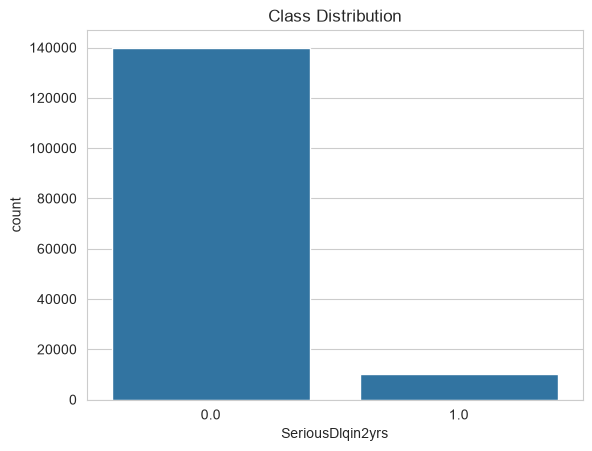

SeriousDlqin2yrs
0.0    139974
1.0     10026
Name: count, dtype: int64

In [30]:
sns.countplot(x='SeriousDlqin2yrs', data=df_labeled)
plt.title("Class Distribution")
plt.show()

df['SeriousDlqin2yrs'].value_counts()